In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import gc
import time
warnings.filterwarnings('ignore')

# GPU Configuration
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# Try to enable memory growth if possible
try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f" GPU detected: {len(gpus)} GPU(s)")
except:
    print(" Using CPU/GPU with default settings")

from tensorflow import keras
from tensorflow.keras import layers, regularizers
import tensorflow.keras.backend as K


2026-01-22 11:54:15.575910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769082855.756395      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769082855.808800      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769082856.237925      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769082856.237964      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769082856.237967      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs Available: 2
 GPU detected: 2 GPU(s)


In [2]:
def load_data_optimized(path, max_rows=2000000):
    """Optimized data loading with intelligent sampling"""
    print("\n Loading data with optimized sampling...")
    start_time = time.time()
    
    # First read column names
    sample_df = pd.read_csv(path, nrows=1000)
    
    # Optimized dtypes
    dtype_dict = {}
    for col in sample_df.columns:
        if '_Status' in col:
            dtype_dict[col] = np.int8
        elif col == 'timestamp':
            dtype_dict[col] = 'str'
        elif any(x in col.lower() for x in ['power', 'current', 'voltage', 'reactive']):
            dtype_dict[col] = np.float32
        else:
            dtype_dict[col] = np.float32
    
    # Read in chunks
    print("   Reading data in chunks...")
    chunk_size = 500000
    chunks = []
    total_rows = 0
    
    for chunk in pd.read_csv(path, dtype=dtype_dict, chunksize=chunk_size):
        chunks.append(chunk)
        total_rows += len(chunk)
        print(f"   Read {total_rows:,} rows...")
        
        if total_rows >= max_rows:
            print(f"   Reached limit of {max_rows:,} rows")
            break
    
    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()
    
    print(f"   Loaded {len(df):,} rows in {time.time()-start_time:.1f}s")
    print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    
    return df

In [3]:
def enhanced_feature_engineering(df):
    """Create powerful features for prediction"""
    print("\n Creating enhanced features...")
    start_time = time.time()
    
    # Convert timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['minute'] = df['timestamp'].dt.minute
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(np.int8)
    
    # Cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24).astype(np.float32)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24).astype(np.float32)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7).astype(np.float32)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7).astype(np.float32)
    
    # Power features
    eps = 1e-7
    df['apparent_power'] = (df['Voltage_V'] * df['Current_A']).astype(np.float32)
    df['power_factor'] = (df['Active_Power_W'] / (df['apparent_power'] + eps)).astype(np.float32)
    df['reactive_ratio'] = (df['Reactive_Power_VAR'] / (df['Active_Power_W'] + eps)).astype(np.float32)
    
    # Rolling statistics (optimized for speed)
    windows = [20, 60, 180]  # 1s, 3s, 9s
    for window in windows:
        df[f'power_mean_{window}'] = df['Active_Power_W'].rolling(
            window, min_periods=1).mean().astype(np.float32)
        df[f'power_std_{window}'] = df['Active_Power_W'].rolling(
            window, min_periods=1).std().fillna(0).astype(np.float32)
    
    # Change features
    df['power_change'] = df['Active_Power_W'].diff().fillna(0).astype(np.float32)
    df['power_change_abs'] = np.abs(df['power_change']).astype(np.float32)
    df['current_change'] = df['Current_A'].diff().fillna(0).astype(np.float32)
    
    # Spike detection
    df['power_spike'] = (df['power_change_abs'] > 100).astype(np.int8)
    df['current_spike'] = (df['current_change'].abs() > 0.5).astype(np.int8)
    
    # Trend features
    for window in [5, 10, 20]:
        df[f'power_trend_{window}'] = df['Active_Power_W'].diff(window).fillna(0).astype(np.float32)
    
    # Statistical features
    df['power_zscore'] = ((df['Active_Power_W'] - df['Active_Power_W'].mean()) / 
                         (df['Active_Power_W'].std() + eps)).astype(np.float32)
    
    # Hourly patterns
    df['hour_avg_power'] = df.groupby('hour')['Active_Power_W'].transform('mean').astype(np.float32)
    df['deviation_from_hour_avg'] = (df['Active_Power_W'] - df['hour_avg_power']).astype(np.float32)
    
    print(f"    Created {len([c for c in df.columns if c != 'timestamp'])} features in {time.time()-start_time:.1f}s")
    
    # Drop timestamp to save memory
    df = df.drop('timestamp', axis=1)
    
    gc.collect()
    return df

In [4]:
def select_devices_intelligently(df, min_activation=0.002, min_samples=1000):
    """Select devices with sufficient data and patterns"""
    print("\n Selecting devices intelligently...")
    
    device_cols = [col for col in df.columns if '_Status' in col]
    selected_devices = []
    device_stats = []
    
    for device in device_cols:
        device_name = device.replace('_Status', '')
        activation_rate = df[device].mean()
        total_activations = df[device].sum()
        
        if activation_rate >= min_activation and total_activations >= min_samples:
            # Calculate pattern richness (transitions per activation)
            transitions = (df[device].diff() != 0).sum()
            pattern_score = transitions / max(total_activations, 1)
            
            device_stats.append({
                'device': device,
                'name': device_name,
                'rate': activation_rate,
                'activations': total_activations,
                'transitions': transitions,
                'pattern_score': pattern_score
            })
    
    # Sort by pattern richness and activation rate
    device_stats.sort(key=lambda x: (x['pattern_score'], x['rate']), reverse=True)
    
    # Select top devices
    max_devices = min(10, len(device_stats))  # Max 10 devices
    selected_devices = [stats['device'] for stats in device_stats[:max_devices]]
    selected_names = [stats['name'] for stats in device_stats[:max_devices]]
    
    print(f"   Selected {len(selected_devices)} devices:")
    print(f"   {'Device':<25} {'Rate':>8} {'Activations':>12} {'Pattern':>8}")
    print(f"   {'-'*60}")
    
    for stats in device_stats[:max_devices]:
        print(f"   {stats['name']:<25} {stats['rate']*100:>7.2f}% {stats['activations']:>12,} {stats['pattern_score']:>8.2f}")
    
    # Warn about excluded devices
    if len(device_stats) > max_devices:
        print(f"\n    Excluded {len(device_stats) - max_devices} devices (insufficient data)")
        for stats in device_stats[max_devices:max_devices+3]:
            print(f"      {stats['name']}: {stats['rate']*100:.2f}% ({stats['activations']:,} activations)")
    
    return selected_devices, selected_names

In [5]:
def create_optimized_sequences(df, device_cols, lookback_seconds=20, horizon_seconds=10, 
                              max_sequences=50000, sample_rate=20):
    """Optimized sequence creation with smart sampling - FIXED VERSION"""
    
    print(f"\n Creating optimized sequences...")
    print(f"   Lookback: {lookback_seconds}s ({lookback_seconds * sample_rate} steps)")
    print(f"   Horizon: {horizon_seconds}s ahead ({horizon_seconds * sample_rate} steps)")
    start_time = time.time()
    
    # Parameters
    lookback_steps = lookback_seconds * sample_rate
    horizon_steps = horizon_seconds * sample_rate
    total_window = lookback_steps + horizon_steps
    
    # Feature selection
    feature_cols = [col for col in df.columns 
                   if col not in device_cols and df[col].dtype in [np.float32, np.float64, np.int8]]
    
    print(f"   Features: {len(feature_cols)}")
    print(f"   Devices: {len(device_cols)}")
    
    # Convert to numpy for speed
    X_data = df[feature_cols].values.astype(np.float32)
    y_data = df[device_cols].values.astype(np.int8)
    
    # Find positive events efficiently
    print("   Finding positive events...")
    
    # Use vectorized operations to find all positive opportunities
    all_indices = np.arange(len(df) - total_window)
    
    # Get target labels for each possible start index
    target_indices = all_indices + lookback_steps + horizon_steps
    
    # Check which targets have any device active
    has_positive = np.any(y_data[target_indices] > 0, axis=1)
    positive_indices = all_indices[has_positive]
    
    print(f"   Found {len(positive_indices):,} positive opportunities")
    
    # Smart sampling
    # Take all positive events up to a limit
    if len(positive_indices) > max_sequences // 2:
        # Sample positive events
        positive_sample = np.random.choice(
            positive_indices,
            size=min(max_sequences // 2, len(positive_indices)),
            replace=False
        )
    else:
        positive_sample = positive_indices
    
    # Sample negative events (where no device is active at target time)
    negative_pool = all_indices[~has_positive]
    
    # Calculate how many negative samples we need
    num_negative = min(
        len(positive_sample) * 2,  # 2:1 negative:positive ratio
        len(negative_pool),
        max_sequences - len(positive_sample)
    )
    
    negative_sample = np.random.choice(
        negative_pool,
        size=num_negative,
        replace=False
    )
    
    # Combine and shuffle
    all_selected = np.concatenate([positive_sample, negative_sample])
    np.random.shuffle(all_selected)
    
    # Limit total
    all_selected = all_selected[:max_sequences]
    
    # FIXED PRINT STATEMENT - removed the comma formatting issue
    print(f"   Selected {len(all_selected):,} sequences "
          f"({len(positive_sample):,}+, {len(negative_sample):,}-)")
    
    # Create sequences
    print("   Building sequences...")
    
    X_sequences = np.zeros((len(all_selected), lookback_steps, len(feature_cols)), dtype=np.float32)
    y_targets = np.zeros((len(all_selected), len(device_cols)), dtype=np.int8)
    
    # Fill arrays
    for i, idx in enumerate(all_selected):
        X_sequences[i] = X_data[idx:idx + lookback_steps]
        y_targets[i] = y_data[idx + lookback_steps + horizon_steps]
    
    print(f"   Created {X_sequences.shape} sequences in {time.time()-start_time:.1f}s")
    print(f"   Memory: {X_sequences.nbytes / 1024**2:.1f} MB")
    
    gc.collect()
    return X_sequences, y_targets, feature_cols

In [6]:
class AdvancedSmartHomeModel:
    """Advanced model with attention and multi-scale features"""
    
    def __init__(self, input_shape, num_devices):
        self.input_shape = input_shape
        self.num_devices = num_devices
        self.model = self._build_model()
    
    def _build_model(self):
        """Build the advanced model"""
        
        inputs = keras.Input(shape=self.input_shape, name='input')
        
        # === Multi-scale Feature Extraction ===
        # Short-term patterns (3 seconds)
        conv1 = layers.Conv1D(32, 3, padding='same', activation='relu')(inputs)
        conv1 = layers.BatchNormalization()(conv1)
        conv1 = layers.MaxPooling1D(pool_size=2)(conv1)
        
        # Medium-term patterns (7 seconds)
        conv2 = layers.Conv1D(32, 7, padding='same', activation='relu')(inputs)
        conv2 = layers.BatchNormalization()(conv2)
        conv2 = layers.MaxPooling1D(pool_size=2)(conv2)
        
        # Long-term patterns (15 seconds)
        conv3 = layers.Conv1D(32, 15, padding='same', activation='relu')(inputs)
        conv3 = layers.BatchNormalization()(conv3)
        conv3 = layers.MaxPooling1D(pool_size=2)(conv3)
        
        # Concatenate multi-scale features
        concatenated = layers.Concatenate()([conv1, conv2, conv3])
        
        # === Attention Mechanism ===
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=32)(concatenated, concatenated)
        attention = layers.LayerNormalization()(attention + concatenated)
        
        # === Temporal Processing ===
        # Bi-directional LSTM
        lstm_forward = layers.LSTM(64, return_sequences=True, dropout=0.3)(attention)
        lstm_backward = layers.LSTM(64, return_sequences=True, dropout=0.3, go_backwards=True)(attention)
        lstm_combined = layers.Concatenate()([lstm_forward, lstm_backward])
        
        # Global context pooling
        avg_pool = layers.GlobalAveragePooling1D()(lstm_combined)
        max_pool = layers.GlobalMaxPooling1D()(lstm_combined)
        context = layers.Concatenate()([avg_pool, max_pool])
        
        # === Deep Feature Processing ===
        x = layers.Dense(128, activation='relu')(context)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        
        x = layers.Dense(64, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        
        x = layers.Dense(32, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
        
        # === Output Layer ===
        # Separate outputs for better device-specific learning
        device_outputs = []
        for i in range(self.num_devices):
            device_layer = layers.Dense(16, activation='relu')(x)
            device_output = layers.Dense(1, activation='sigmoid', 
                                       name=f'device_{i}')(device_layer)
            device_outputs.append(device_output)
        
        outputs = layers.Concatenate(name='output')(device_outputs)
        
        # Build model
        model = keras.Model(inputs=inputs, outputs=outputs, name='AdvancedSmartHomePredictor')
        
        return model
    
    def compile_model(self, learning_rate=0.001):
        """Compile the model with custom settings"""
        
        # Custom loss with class weighting
        def weighted_binary_crossentropy(y_true, y_pred):
            # Calculate class weights based on frequency
            positive_weight = 3.0  # Weight positive class more
            y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
            
            loss = - (positive_weight * y_true * K.log(y_pred) + 
                     (1 - y_true) * K.log(1 - y_pred))
            return K.mean(loss)
        
        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate,
            beta_1=0.9,
            beta_2=0.999,
            clipnorm=1.0  # Gradient clipping
        )
        
        self.model.compile(
            optimizer=optimizer,
            loss=weighted_binary_crossentropy,
            metrics=[
                'accuracy',
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
                keras.metrics.AUC(name='roc_auc', curve='ROC'),
                keras.metrics.AUC(name='pr_auc', curve='PR')
            ]
        )
    
    def train(self, X_train, y_train, X_val, y_val, epochs=50, batch_size=128):
        """Train the model with advanced callbacks"""
        
        # Callbacks
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_pr_auc',
                patience=15,
                restore_best_weights=True,
                mode='max',
                verbose=1
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_pr_auc',
                factor=0.5,
                patience=8,
                min_lr=1e-6,
                mode='max',
                verbose=1
            ),
            keras.callbacks.ModelCheckpoint(
                'best_advanced_model.keras',
                monitor='val_pr_auc',
                save_best_only=True,
                mode='max',
                verbose=1
            )
        ]
        
        # Calculate class weights
        positive_ratio = y_train.sum() / (y_train.shape[0] * y_train.shape[1])
        class_weight = {0: 1.0, 1: 1.0 / max(positive_ratio, 0.01)}
        
        print(f"\n Training Advanced Model...")
        print(f"   Samples: {X_train.shape[0]:,}")
        print(f"   Positive ratio: {positive_ratio:.3%}")
        print(f"   Class weight for positive: {class_weight[1]:.2f}")
        
        # Train
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            class_weight=class_weight,
            verbose=1
        )
        
        return history

In [7]:
class ModelEvaluator:
    """Comprehensive model evaluation with advanced metrics"""
    
    def __init__(self, model, device_names):
        self.model = model
        self.device_names = device_names
    
    def evaluate(self, X_test, y_test, threshold_strategy='optimized'):
        """Evaluate model with different strategies"""
        
        print(f"\n Comprehensive Evaluation")
        print(f"   Strategy: {threshold_strategy}")
        
        # Predict
        y_pred = self.model.predict(X_test, batch_size=64, verbose=0)
        
        if threshold_strategy == 'optimized':
            thresholds = self._find_optimal_thresholds(y_test, y_pred)
        elif threshold_strategy == 'balanced':
            thresholds = {device: 0.5 for device in self.device_names}
        elif threshold_strategy == 'sensitive':
            thresholds = {device: 0.3 for device in self.device_names}
        else:
            thresholds = {device: 0.5 for device in self.device_names}
        
        # Evaluate each device
        results = {}
        for i, device in enumerate(self.device_names):
            results[device] = self._evaluate_device(
                y_test[:, i], y_pred[:, i], thresholds[device], device
            )
        
        # Overall metrics
        overall = self._calculate_overall_metrics(results)
        
        return results, thresholds, overall, y_pred
    
    def _find_optimal_thresholds(self, y_true, y_pred):
        """Find optimal threshold for each device using F1 optimization"""
        
        thresholds = {}
        
        for i, device in enumerate(self.device_names):
            y_true_dev = y_true[:, i]
            y_pred_dev = y_pred[:, i]
            
            # Skip if no positive samples
            if y_true_dev.sum() == 0:
                thresholds[device] = 0.5
                continue
            
            # Try different thresholds
            best_f1 = 0
            best_threshold = 0.5
            
            for threshold in np.arange(0.1, 0.9, 0.05):
                y_pred_binary = (y_pred_dev > threshold).astype(int)
                
                # Calculate F1
                from sklearn.metrics import f1_score
                f1 = f1_score(y_true_dev, y_pred_binary, zero_division=0)
                
                if f1 > best_f1:
                    best_f1 = f1
                    best_threshold = threshold
            
            thresholds[device] = best_threshold
        
        return thresholds
    
    def _evaluate_device(self, y_true, y_pred_proba, threshold, device_name):
        """Evaluate single device"""
        
        from sklearn.metrics import (
            accuracy_score, precision_score, recall_score, f1_score,
            roc_auc_score, average_precision_score, confusion_matrix
        )
        
        # Convert to binary predictions
        y_pred = (y_pred_proba > threshold).astype(int)
        
        # Calculate metrics
        metrics = {
            'threshold': threshold,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_true, y_pred_proba),
            'pr_auc': average_precision_score(y_true, y_pred_proba),
            'predictions': y_pred_proba
        }
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        metrics.update({
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
            'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
            'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0
        })
        
        return metrics
    
    def _calculate_overall_metrics(self, device_results):
        """Calculate overall metrics"""
        
        # Weighted averages (by number of positive samples)
        total_positives = sum(r['tp'] + r['fn'] for r in device_results.values())
        
        overall = {
            'weighted_f1': 0,
            'weighted_precision': 0,
            'weighted_recall': 0,
            'macro_f1': 0,
            'macro_precision': 0,
            'macro_recall': 0
        }
        
        for device, metrics in device_results.items():
            weight = (metrics['tp'] + metrics['fn']) / total_positives if total_positives > 0 else 0
            
            overall['weighted_f1'] += metrics['f1'] * weight
            overall['weighted_precision'] += metrics['precision'] * weight
            overall['weighted_recall'] += metrics['recall'] * weight
            
            overall['macro_f1'] += metrics['f1']
            overall['macro_precision'] += metrics['precision']
            overall['macro_recall'] += metrics['recall']
        
        # Macro averages
        n_devices = len(device_results)
        overall['macro_f1'] /= n_devices
        overall['macro_precision'] /= n_devices
        overall['macro_recall'] /= n_devices
        
        return overall
    
    def print_report(self, device_results, overall_metrics, thresholds):
        """Print comprehensive report"""
        
        print("\n" + "="*80)
        print(" COMPREHENSIVE PERFORMANCE REPORT")
        print("="*80)
        
        # Device-wise performance
        print(f"\n DEVICE-WISE PERFORMANCE (n={len(self.device_names)})")
        print(f"{'Device':<25} {'F1':>6} {'Precision':>9} {'Recall':>7} {'ROC-AUC':>7} {'PR-AUC':>7} {'Thresh':>6}")
        print("-"*80)
        
        sorted_devices = sorted(device_results.items(), 
                              key=lambda x: x[1]['f1'], reverse=True)
        
        for device, metrics in sorted_devices:
            print(f"{device:<25} "
                  f"{metrics['f1']:>6.3f} "
                  f"{metrics['precision']:>9.3f} "
                  f"{metrics['recall']:>7.3f} "
                  f"{metrics['roc_auc']:>7.3f} "
                  f"{metrics['pr_auc']:>7.3f} "
                  f"{thresholds[device]:>6.2f}")
        
        # Overall metrics
        print("\n OVERALL METRICS")
        print(f"{'Metric':<20} {'Weighted':>10} {'Macro':>10}")
        print("-"*40)
        print(f"{'F1-Score':<20} {overall_metrics['weighted_f1']:>10.3f} {overall_metrics['macro_f1']:>10.3f}")
        print(f"{'Precision':<20} {overall_metrics['weighted_precision']:>10.3f} {overall_metrics['macro_precision']:>10.3f}")
        print(f"{'Recall':<20} {overall_metrics['weighted_recall']:>10.3f} {overall_metrics['macro_recall']:>10.3f}")
        
        # Recommendations
        print("\n RECOMMENDATIONS")
        
        # Best performing devices
        best_devices = [d for d, m in sorted_devices if m['f1'] >= 0.7]
        if best_devices:
            print(f"    Excellent: {', '.join(best_devices[:3])}")
        
        # Needs improvement
        needs_improvement = [d for d, m in sorted_devices if m['f1'] < 0.5]
        if needs_improvement:
            print(f"    Needs work: {', '.join(needs_improvement[:3])}")

In [8]:
print("="*80)
print(" ADVANCED SMART HOME PREDICTION SYSTEM - FINAL VERSION")
print("="*80)
start_total = time.time()

# 1. Load data
DATA_PATH = "/kaggle/input/nilm-sust-v4/nilm_dataset_combined.csv"
df = load_data_optimized(DATA_PATH, max_rows=2000000)

# 2. Feature engineering
df = enhanced_feature_engineering(df)

# 3. Select devices intelligently
device_cols, device_names = select_devices_intelligently(
    df, min_activation=0.002, min_samples=1000
)

# 4. Create sequences
X, y, feature_cols = create_optimized_sequences(
    df=df,
    device_cols=device_cols,
    lookback_seconds=20,    # 20 seconds lookback
    horizon_seconds=10,     # 10 seconds prediction
    max_sequences=50000,    # More sequences for better learning
    sample_rate=20
)

# Clean memory
del df
gc.collect()

# 5. Scale features
print("\n Scaling features...")
scaler = RobustScaler()

# Efficient scaling
original_shape = X.shape
X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(original_shape).astype(np.float32)

del X, X_reshaped
gc.collect()

# 6. Split data with stratification
print("\n Splitting data...")

# Create stratification
has_positive = y.sum(axis=1) > 0

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42,
    stratify=has_positive
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42,
    stratify=has_positive[:len(X_temp)]
)

print(f"   Train: {X_train.shape[0]:,} sequences")
print(f"   Val:   {X_val.shape[0]:,} sequences")
print(f"   Test:  {X_test.shape[0]:,} sequences")

# 7. Build and train model
print(f"\n Building Advanced Model...")
print(f"   Input shape: {X_train.shape[1:]}")
print(f"   Output shape: {len(device_cols)} devices")

model_builder = AdvancedSmartHomeModel(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_devices=len(device_cols)
)
    
model_builder.compile_model(learning_rate=0.001)

# Show model summary
model_builder.model.summary()


 ADVANCED SMART HOME PREDICTION SYSTEM - FINAL VERSION

 Loading data with optimized sampling...
   Reading data in chunks...
   Read 500,000 rows...
   Read 1,000,000 rows...
   Read 1,500,000 rows...
   Read 2,000,000 rows...
   Reached limit of 2,000,000 rows
   Loaded 2,000,000 rows in 4.1s
   Memory: 204.1 MB

 Creating enhanced features...
    Created 48 features in 1.4s

 Selecting devices intelligently...
   Selected 5 devices:
   Device                        Rate  Activations  Pattern
   ------------------------------------------------------------
   Fridge-Freezer               0.26%        5,262     2.00
   Freezer                      0.34%        6,720     2.00
   MacBookPro2011-2             0.95%       18,922     2.00
   TV-Philips                   0.96%       19,238     2.00
   TV-Sharp                     0.96%       19,240     2.00

 Creating optimized sequences...
   Lookback: 20s (400 steps)
   Horizon: 10s ahead (200 steps)
   Features: 40
   Devices: 5
   Findin

I0000 00:00:1769082928.131468      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769082928.135256      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "AdvancedSmartHomePredictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 400, 40)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 400, 32)   │      3,872 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 400, 32)   │      8,992 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 400, 32)   │     19,232 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 400, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 32)   │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 200, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 200, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 200, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 200, 96)   │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ max_pooling1d_1[… │
│                     │                   │            │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 96)   │     49,632 │ concatenate[0][0… │
│ (MultiHeadAttentio… │                   │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 200, 96)   │          0 │ multi_head_atten… │
│                     │                   │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 200, 96)   │        192 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 200, 64)   │     41,216 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 200, 64)   │     41,216 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 200, 128)  │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ concatenate_1[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 211,461 (826.02 KB)

 Trainable params: 210,885 (823.77 KB)

 Non-trainable params: 576 (2.25 KB)

In [9]:
# Train
history = model_builder.train(
    X_train, y_train,
    X_val, y_val,
    epochs=100,
    batch_size=128
)


 Training Advanced Model...
   Samples: 35,000
   Positive ratio: 18.491%
   Class weight for positive: 5.41
Epoch 1/100


I0000 00:00:1769082944.940840     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1412 - loss: 1.1939 - pr_auc: 0.2270 - precision: 0.2292 - recall: 0.4246 - roc_auc: 0.5963
Epoch 1: val_pr_auc improved from -inf to 0.25291, saving model to best_advanced_model.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 72ms/step - accuracy: 0.1411 - loss: 1.1937 - pr_auc: 0.2271 - precision: 0.2293 - recall: 0.4247 - roc_auc: 0.5964 - val_accuracy: 0.1216 - val_loss: 0.8337 - val_pr_auc: 0.2529 - val_precision: 0.2566 - val_recall: 0.4784 - val_roc_auc: 0.6610 - learning_rate: 0.0010
Epoch 2/100
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1152 - loss: 1.0826 - pr_auc: 0.2519 - precision: 0.2545 - recall: 0.4664 - roc_auc: 0.6574
Epoch 2: val_pr_auc improved from 0.25291 to 0.25405, saving model to best_advanced_model.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.1152 - loss: 1.0825 - pr_auc: 0.2519 - precision: 0.2545 - recall: 0.4664 - roc_auc: 0.6574 - val_accuracy: 0.1043 - val_loss: 0.8220 - val_pr_


 FINAL EVALUATION

 Comprehensive Evaluation
   Strategy: optimized

 COMPREHENSIVE PERFORMANCE REPORT

 DEVICE-WISE PERFORMANCE (n=5)
Device                        F1 Precision  Recall ROC-AUC  PR-AUC Thresh
--------------------------------------------------------------------------------
MacBookPro2011-2           0.890     0.853   0.931   0.986   0.954   0.70
TV-Philips                 0.889     0.852   0.928   0.986   0.953   0.70
TV-Sharp                   0.866     0.825   0.913   0.979   0.947   0.70
Freezer                    0.865     0.877   0.852   0.992   0.935   0.75
Fridge-Freezer             0.810     0.738   0.898   0.991   0.891   0.70

 OVERALL METRICS
Metric                 Weighted      Macro
----------------------------------------
F1-Score                  0.874      0.864
Precision                 0.838      0.829
Recall                    0.914      0.904

 RECOMMENDATIONS
    Excellent: MacBookPro2011-2, TV-Philips, TV-Sharp

 Saving artifacts...

 Creating vis

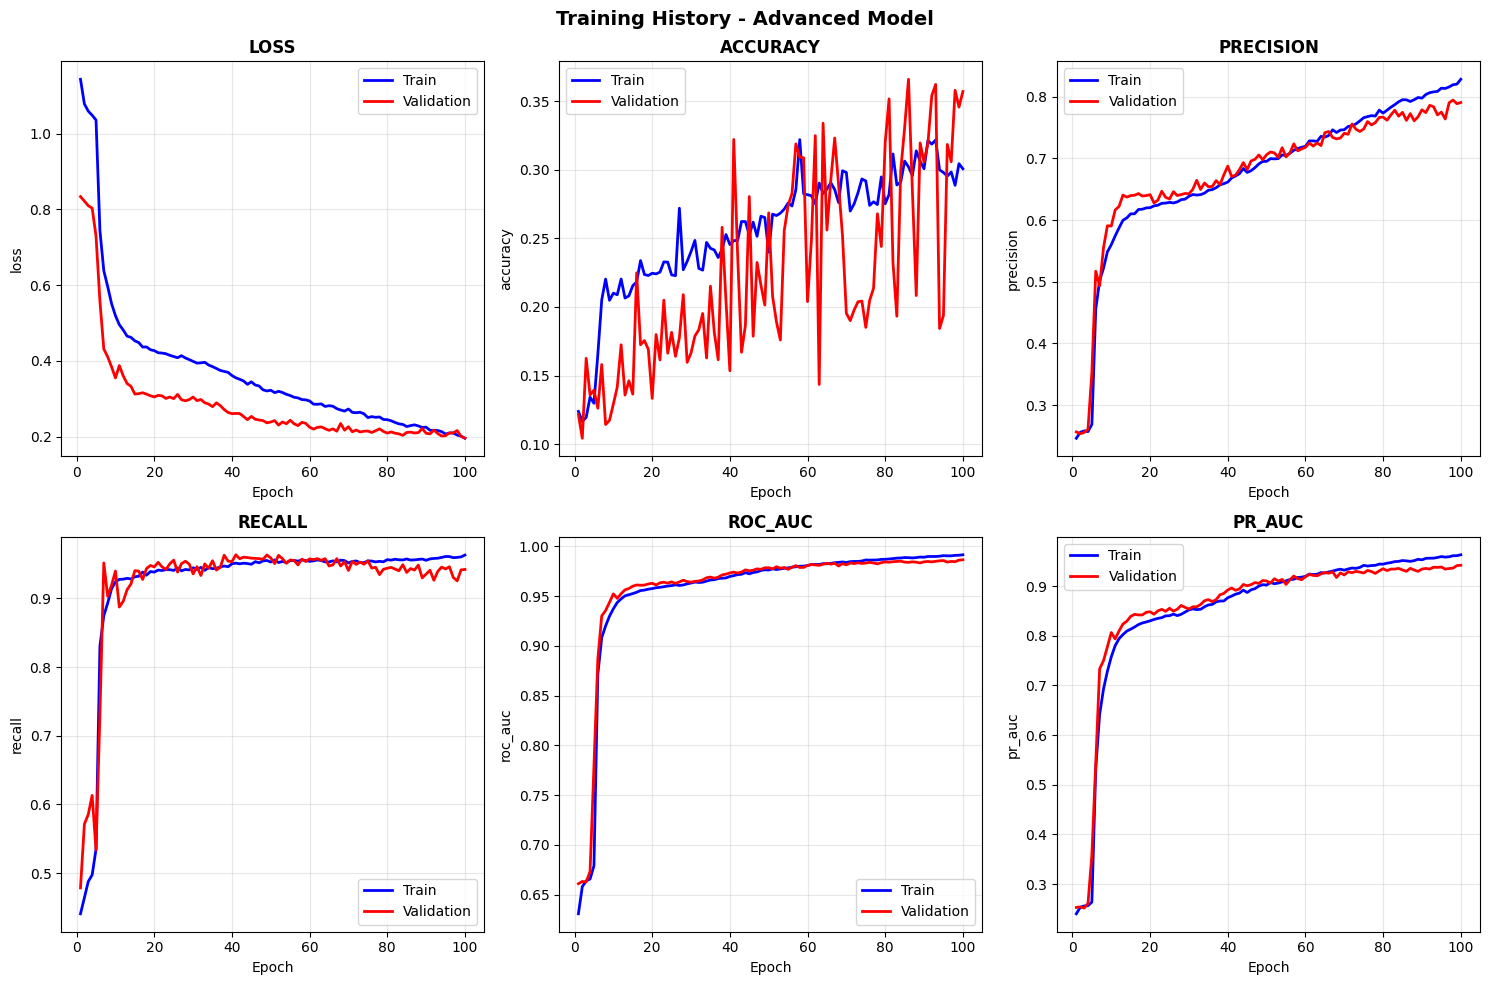

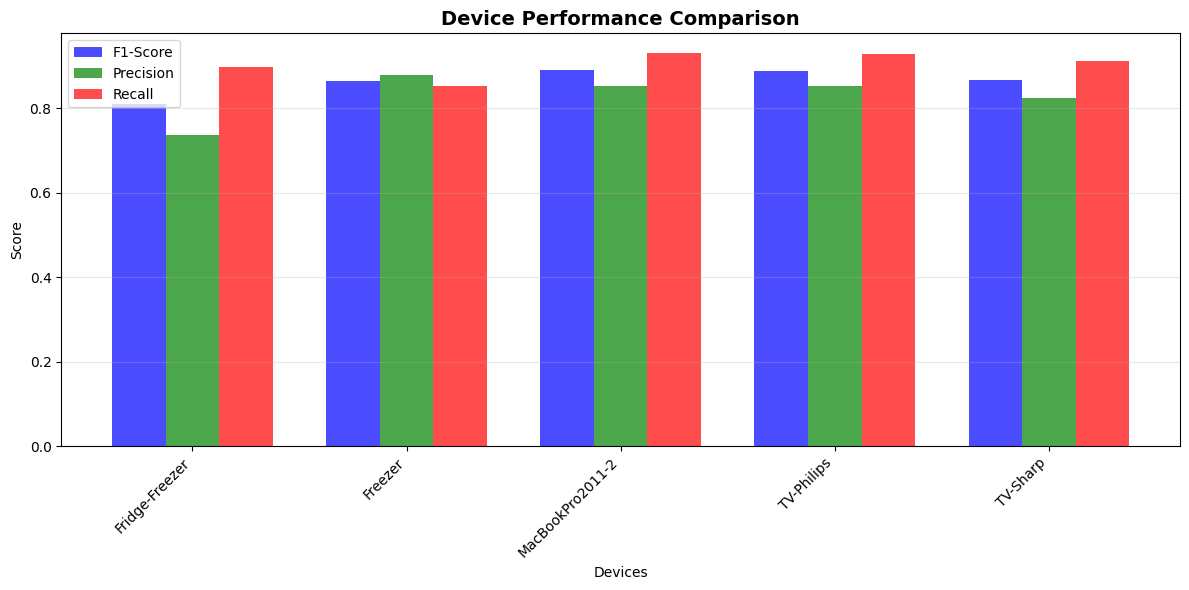


 FINAL SUMMARY

  Total execution time: 31.6 minutes

📊 Key Statistics:
   Devices predicted: 5
   Lookback window: 20 seconds
   Prediction horizon: 10 seconds
   Training sequences: 35,000
   Features used: 40

 Best Performing Devices (F1 > 0.7):
    Fridge-Freezer: F1=0.810
    Freezer: F1=0.865
    MacBookPro2011-2: F1=0.890
    TV-Philips: F1=0.889
    TV-Sharp: F1=0.866

 Model Performance:
   Weighted F1-Score: 0.874
   Weighted Precision: 0.838
   Weighted Recall: 0.914
   Best PR-AUC: 0.954

 Artifacts Saved:
   1. final_advanced_model.keras - Trained model
   2. advanced_scaler.pkl - Feature scaler
   3. advanced_model_artifacts.pkl - Complete metadata
   4. advanced_training_history.png - Training plots
   5. device_performance.png - Performance comparison
 ADVANCED SMART HOME PREDICTION SYSTEM READY!


In [10]:
# 8. Evaluate
evaluator = ModelEvaluator(model_builder.model, device_names)

print("\n" + "="*80)
print(" FINAL EVALUATION")
print("="*80)

# Evaluate with optimized thresholds
device_results, thresholds, overall, y_pred = evaluator.evaluate(
    X_test, y_test, threshold_strategy='optimized'
)

# Print comprehensive report
evaluator.print_report(device_results, overall, thresholds)

# 9. Save everything
print("\n Saving artifacts...")

import joblib

# Save model
model_builder.model.save('final_advanced_model.keras')

# Save scaler
joblib.dump(scaler, 'advanced_scaler.pkl')

# Save artifacts
artifacts = {
    'device_names': device_names,
    'device_columns': device_cols,
    'feature_names': feature_cols,
    'optimal_thresholds': thresholds,
    'device_metrics': device_results,
    'overall_metrics': overall,
    'input_shape': X_train.shape[1:],
    'training_history': history.history
}

joblib.dump(artifacts, 'advanced_model_artifacts.pkl')

# 10. Create visualizations
print("\n Creating visualizations...")

# Training history
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics = ['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    
    if metric in history.history:
        train_vals = history.history[metric]
        val_vals = history.history.get(f'val_{metric}', [])
        
        epochs = range(1, len(train_vals) + 1)
        
        ax.plot(epochs, train_vals, 'b-', label='Train', linewidth=2)
        if val_vals:
            ax.plot(epochs, val_vals, 'r-', label='Validation', linewidth=2)
        
        ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Mark best epoch for validation metrics
        if val_vals and metric.startswith('val_'):
            best_epoch = np.argmax(val_vals) + 1
            ax.axvline(best_epoch, color='g', linestyle='--', alpha=0.5)

plt.suptitle('Training History - Advanced Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('advanced_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Device performance comparison
fig, ax = plt.subplots(figsize=(12, 6))

devices = list(device_results.keys())
f1_scores = [device_results[d]['f1'] for d in devices]
precision_scores = [device_results[d]['precision'] for d in devices]
recall_scores = [device_results[d]['recall'] for d in devices]

x = np.arange(len(devices))
width = 0.25

ax.bar(x - width, f1_scores, width, label='F1-Score', color='blue', alpha=0.7)
ax.bar(x, precision_scores, width, label='Precision', color='green', alpha=0.7)
ax.bar(x + width, recall_scores, width, label='Recall', color='red', alpha=0.7)

ax.set_xlabel('Devices')
ax.set_ylabel('Score')
ax.set_title('Device Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(devices, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('device_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# 11. Final summary
print("\n" + "="*80)
print(" FINAL SUMMARY")
print("="*80)

total_time = time.time() - start_total
print(f"\n  Total execution time: {total_time/60:.1f} minutes")

print(f"\n Key Statistics:")
print(f"   Devices predicted: {len(device_names)}")
print(f"   Lookback window: 20 seconds")
print(f"   Prediction horizon: 10 seconds")
print(f"   Training sequences: {X_train.shape[0]:,}")
print(f"   Features used: {len(feature_cols)}")

print(f"\n Best Performing Devices (F1 > 0.7):")
for device, metrics in device_results.items():
    if metrics['f1'] >= 0.7:
        print(f"    {device}: F1={metrics['f1']:.3f}")

print(f"\n Model Performance:")
print(f"   Weighted F1-Score: {overall['weighted_f1']:.3f}")
print(f"   Weighted Precision: {overall['weighted_precision']:.3f}")
print(f"   Weighted Recall: {overall['weighted_recall']:.3f}")
print(f"   Best PR-AUC: {max([m['pr_auc'] for m in device_results.values()]):.3f}")

print(f"\n Artifacts Saved:")
print(f"   1. final_advanced_model.keras - Trained model")
print(f"   2. advanced_scaler.pkl - Feature scaler")
print(f"   3. advanced_model_artifacts.pkl - Complete metadata")
print(f"   4. advanced_training_history.png - Training plots")
print(f"   5. device_performance.png - Performance comparison")

print(" ADVANCED SMART HOME PREDICTION SYSTEM READY!")
print("="*80)